# Quantum Walk Search Workflow

This notebook uses the package-level `quantum_walk_search_workflow` to study a
small continuous-time quantum walk search instance. The workflow constructs the
search Hamiltonian, samples exact marked-vertex probability, and validates a
QSVT-style polynomial phase approximation at the best sampled search time.

The example is intentionally finite and dense. It demonstrates amplitude
amplification toward a marked vertex and the polynomial-transform view of the
search propagator; it does not claim a scalable oracle implementation.

## Problem Statement

Continuous-time search on a graph uses a Hamiltonian

$$H = -\gamma A - |m\rangle\langle m|,$$

where `A` is the graph adjacency matrix, `gamma` is the hopping rate, and
`|m>` is the marked vertex. Starting from the uniform state, the search
dynamics amplify probability on the marked vertex.

**System/problem.** We use a four-vertex complete graph with one marked vertex.

**QSVT implementation.** The workflow rescales the search Hamiltonian and fits
real polynomials for the cosine and sine parts of `exp(-i H t)` at the best
sampled time.

**Classical reference and quantum relevance.** Dense spectral evolution gives
the exact reference probability curve. The polynomial result is a finite
QSVT-style matrix-function validation, with oracle construction, state
preparation, phase synthesis, and readout costs reported as omitted layers.

## Imports

The tutorial imports only the workflow, report conversion helper, and standard
plotting/numerical tools.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np

from qsvt.algorithms import quantum_walk_search_workflow
from qsvt.reports import report_to_jsonable

## Search Instance

For a complete graph on `n` vertices, the default workflow hopping rate is
`gamma = 1 / n`. The default initial state is the uniform superposition.

In [2]:
n_vertices = 4
marked_vertex = 0
adjacency = np.ones((n_vertices, n_vertices), dtype=float) - np.eye(n_vertices)

print("Adjacency matrix:")
print(adjacency)

Adjacency matrix:
[[0. 1. 1. 1.]
 [1. 0. 1. 1.]
 [1. 1. 0. 1.]
 [1. 1. 1. 0.]]


## Run The Workflow

The workflow samples exact dense time evolution on a small grid, selects the
best marked-vertex probability, and then approximates the best-time propagator
with polynomial cosine and sine components.

In [3]:
result = quantum_walk_search_workflow(
    adjacency,
    marked_vertex=marked_vertex,
    degree=14,
    num_points=801,
    num_time_points=121,
)

print(f"gamma = {result.gamma:.3f}")
print(f"best sampled time = {result.best_time:.6f}")
print(f"best marked probability = {result.best_probability:.12f}")
print(f"polynomial marked probability = {result.polynomial_marked_probability:.12f}")
print(f"probability error = {result.probability_error:.3e}")
print(f"state relative error = {result.state_relative_error:.3e}")

gamma = 0.250
best sampled time = 3.141593
best marked probability = 1.000000000000
polynomial marked probability = 1.000000000061
probability error = 6.125e-11
state relative error = 3.520e-11


## Marked-Vertex Probability

The probability curve shows amplitude amplification from the uniform initial
state to the marked vertex.

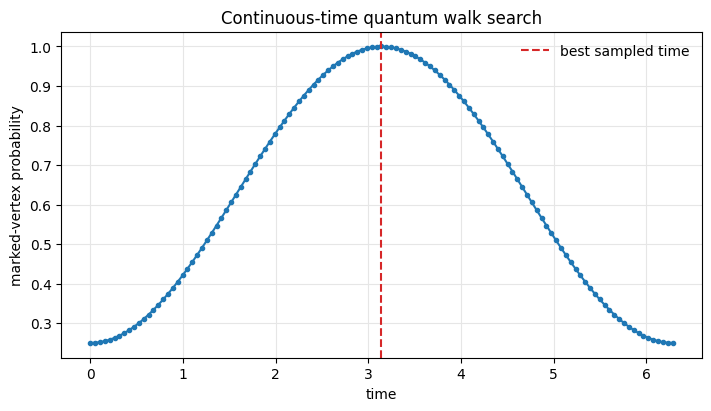

In [4]:
fig, ax = plt.subplots(figsize=(7.0, 4.0), constrained_layout=True)
ax.plot(result.times, result.marked_probabilities, marker="o", markersize=3)
ax.axvline(result.best_time, color="tab:red", linestyle="--", label="best sampled time")
ax.set_xlabel("time")
ax.set_ylabel("marked-vertex probability")
ax.set_title("Continuous-time quantum walk search")
ax.grid(True, color="0.9")
ax.legend(frameon=False)
plt.show()

## Polynomial Phase Approximation

At the best sampled search time, the workflow compares exact dense evolution
with the polynomial approximation to the real and imaginary phase components.

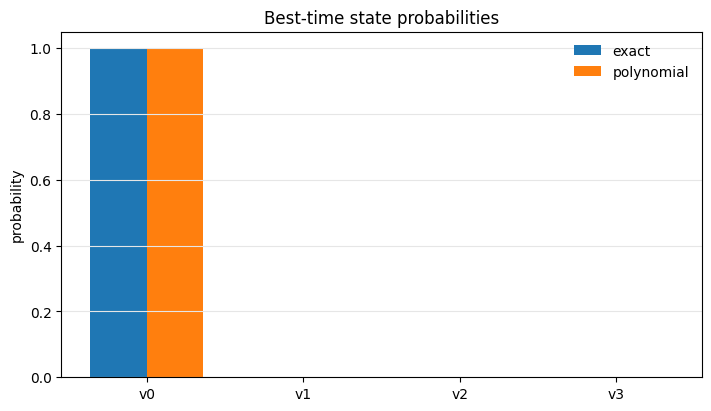

In [5]:
labels = [f"v{i}" for i in range(n_vertices)]
exact_probs = np.abs(result.exact_best_state) ** 2
poly_probs = np.abs(result.polynomial_best_state) ** 2

fig, ax = plt.subplots(figsize=(7.0, 4.0), constrained_layout=True)
x = np.arange(n_vertices)
width = 0.36
ax.bar(x - width / 2, exact_probs, width, label="exact")
ax.bar(x + width / 2, poly_probs, width, label="polynomial")
ax.set_xticks(x, labels)
ax.set_ylabel("probability")
ax.set_title("Best-time state probabilities")
ax.grid(True, axis="y", color="0.9")
ax.legend(frameon=False)
plt.show()

## Report And Claim Boundary

The report records the finite workflow outputs and the omitted quantum layers.
The resource proxy counts polynomial degree and signal-call proxies; it is not a
hardware runtime estimate.

In [6]:
report = report_to_jsonable(result.as_report())
print("mode:", report["mode"])
print("truth status:", report["truth_contract"]["truth_status"])
print("resource proxy:")
for key in [
    "proxy_kind",
    "graph_vertices",
    "degree",
    "qsp_phase_count",
    "signal_call_proxy",
    "requires_graph_oracle",
    "requires_marking_oracle",
]:
    print(f"  {key}: {report['resource_proxy'][key]}")
print("omitted layers:")
for layer in report["resource_proxy"]["omitted_layers"]:
    print("  -", layer)

mode: quantum-walk-search-workflow
truth status: validated_polynomial_core
resource proxy:
  proxy_kind: quantum-walk-search-resource-proxy
  graph_vertices: 4
  degree: 14
  qsp_phase_count: 15
  signal_call_proxy: 14
  requires_graph_oracle: True
  requires_marking_oracle: True
omitted layers:
  - graph_oracle_or_sparse_walk_construction
  - marked_vertex_oracle_construction
  - initial_state_preparation
  - QSP_or_QSVT_phase_synthesis
  - success_probability_estimation_or_sampling
  - hardware_noise_and_fault_tolerance


## What This Implements

This tutorial implements a dense finite search Hamiltonian, exact spectral
reference dynamics, and a polynomial matrix-function approximation at the best
sampled time. To turn the pattern into a scalable quantum algorithm, a caller
would still need graph access oracles, a marking oracle, state preparation,
phase synthesis, and a readout or amplitude-estimation strategy.